SNAP Participation Among Native-Born and Foreign-Born Individuals: A Comparison of New York and Texas
Final Project - Yadira Farias 

 Introduction/Justification 

Public assistance programs such as the Supplemental Nutrition Assistance Program (SNAP) play a significant role in supporting individuals and families experiencing economic hardship in the United States. Despite the program’s importance, there continues to be considerable public debate regarding the extent to which immigrants utilize government assistance programs compared to native-born citizens. These discussions often shape public policy and public perception, yet they are not always grounded in empirical data.

This study examines differences in SNAP participation between native-born and foreign-born individuals in the states of New York and Texas. These states were selected due to their large immigrant populations and differing political and economic environments. Using data obtained from IPUMS, this analysis evaluates whether nativity status is associated with differences in SNAP usage and whether those patterns vary between the two states. Understanding these patterns can contribute to a more informed discussion regarding immigration and public assistance in the United States.


Research Questions and Hypotheses 

The primary research quesiton guiding this analysis is:
**Do foreign-born individuals use SNAP benefits at different rates compared to native-born individuals in New York and Texas?**
To investigate this question, the following hypotheses were tested: 
**H1:** There is a statistically significant difference in SNAP participation between native-born and foreign-born individuals.
**H2:** SNAP participation differs by state, with variation between New York and Texas.
**H3:** The relationship between nativity and SNAP participation may vary depending on the state of residence.

### Data Description 
The dataset used in this study was obtained from the Integrated Public Use Microdata Series (IPUMS). IPUMS provides harmonized census and survey data that allow researchers to analyze demographic, economic, and social characteristics of populations within the United States.

For this analysis, variables related to SNAP participation, nativity status, state of residence, income, age, and education were extracted. The dataset was filtered to include only respondents residing in New York and Texas in order to allow for a direct comparison between the two states.

SNAP participation was treated as the primary outcome variable, while nativity status served as the key independent variable. Additional demographic variables were included in the analysis to control for socioeconomic differences that may influence SNAP participation.

### Importing the Dataset and Preparing the IPUMS Files

To begin the analysis, several Python Libraries were imported. The pandas library is used for data manipulation and analysis, while pathlib helps manage file paths within the working environment. These tools allow the dataset to be loaded and processed effeciently within the Jupyter Notebook. 

Next, the file paths for the IPUMS data file and the XML metadata file were defined. Confirmation was perform to test if both files were successfully located in the working directory. 


In [26]:
# Import standard libraries for file path 
from pathlib import Path 

# Import pandas for data handling 
import pandas as pd 

In [27]:
# Define paths to the IPUMS files 
dat_path = Path("usa_2023ACS5Y.dat")
xml_path = Path("usa_DDI2023ACS5Y.xml")

# Confirm the files exist
dat_path.exists(), xml_path.exists()

(True, True)

IPUMS datasets are distributed as fixed-width files, the XML metadata file must be parsed to identify the variables included in the dataset and the corresponding column positions. The xml.etree.ElementTree library is used to read the XML file and extract the necessary information that will later be used to properly load the dataset into a structured format.

In [28]:
# Parse the IPUMS DDI XML file to get variables names and column start/end positions
import xml.etree.ElementTree as ET

# Parse the XML metadata file 
tree = ET.parse(xml_path)
root = tree.getroot()

# Print the root tage to see the namespace 
root.tag



'{ddi:codebook:2_5}codeBook'

### Extracting Variable Information from the XML File
The XML metadata file provided by IPUMS includes information about the variables contained in the dataset. Because the XML file uses a namespace, it must first be defined so Python can properly locate the elements within the document.

Next, the code searches the XML structure to identify the variable tags. Since namespace formatting can sometimes interfere with direct searches, an additional loop is used to locate elements whose tag ends with "var". This approach ensures that all variables included in the IPUMS dataset are correctly identified.

In [4]:

# The XML uses a namespace. Define it here 
ns = {"ddi": "ddi.codebook:2_5"}

# Find all variables in the DDI file using the namespace-aware path 
vars_found = root.findall(".//ddi:var", ns) 

# Quick check: how many variables found?
len(vars_found)


0

In [29]:
# Show the tags of the first 15 direct children of the root 
for i, child in enumerate(list(root)[:15]):
    print(i, child.tag)

0 {ddi:codebook:2_5}docDscr
1 {ddi:codebook:2_5}stdyDscr
2 {ddi:codebook:2_5}fileDscr
3 {ddi:codebook:2_5}dataDscr


In [30]:
# Find all elements whose tag name ends with 'var'
# This avoids namespace issues and works reliably for IPUMS DDI files

vars_found = []

for elem in root.iter():
    # XML tags include the namespace, to check how the tag name ends
    if elem.tag.endswith("var"):
        vars_found.append(elem)

# How many variables found?
len(vars_found)

19

### Identifying Variable Structure and Column Positions
The XML metadata file is examined to understand how variables are defined in the IPUMS dataset. Inspecting a sample variable helps identify where key information such as variable names and column locations are stored.


In [31]:
# Look at the first variable entry to see:
# - the variable name
# - where the start/end positions are stored in the XML

first_var = vars_found[0]

print("Tag:", first_var.tag)
print("Attributes:", first_var.attrib)

# Print the child tags for this variable (helps locate the position info)
for child in list(first_var):
    print("  Child tag:", child.tag, " | attributes:", child.attrib)

Tag: {ddi:codebook:2_5}var
Attributes: {'ID': 'YEAR', 'dcml': '0', 'files': 'ExtractData', 'intrvl': 'discrete', 'name': 'YEAR'}
  Child tag: {ddi:codebook:2_5}location  | attributes: {'EndPos': '4', 'StartPos': '1', 'width': '4'}
  Child tag: {ddi:codebook:2_5}labl  | attributes: {}
  Child tag: {ddi:codebook:2_5}txt  | attributes: {}
  Child tag: {ddi:codebook:2_5}catgry  | attributes: {}
  Child tag: {ddi:codebook:2_5}catgry  | attributes: {}
  Child tag: {ddi:codebook:2_5}catgry  | attributes: {}
  Child tag: {ddi:codebook:2_5}catgry  | attributes: {}
  Child tag: {ddi:codebook:2_5}catgry  | attributes: {}
  Child tag: {ddi:codebook:2_5}catgry  | attributes: {}
  Child tag: {ddi:codebook:2_5}catgry  | attributes: {}
  Child tag: {ddi:codebook:2_5}catgry  | attributes: {}
  Child tag: {ddi:codebook:2_5}catgry  | attributes: {}
  Child tag: {ddi:codebook:2_5}catgry  | attributes: {}
  Child tag: {ddi:codebook:2_5}catgry  | attributes: {}
  Child tag: {ddi:codebook:2_5}catgry  | attri

The variable definitions are then used to extract the column names and their corresponding start and end positions. These positions will later be used to correctly read the fixed-width data file into a structured dataframe using pandas.

In [32]:
# Need to extract:
# 1) column names
# 2) column start and end positions
# from the XML variable definitions

col_names = []     # list to store column names
col_specs = []     # list to store (start, end) positions for pandas

for var in vars_found:
    # Get the variable name (e.g., YEAR, AGE, BPL)
    var_name = var.attrib.get("name")
    
    # Find the <location> child that stores start/end positions
    location = None
    for child in var:
        if child.tag.endswith("location"):
            location = child
            break
    
    # Skip if no location info is found (safety check)
    if location is None:
        continue
    
    # Extract start and end positions (IPUMS is 1-based)
    start_pos = int(location.attrib["StartPos"]) - 1  # convert to 0-based
    end_pos = int(location.attrib["EndPos"])          # pandas end is exclusive
    
    # Store results
    col_names.append(var_name)
    col_specs.append((start_pos, end_pos))

# Quick check: how many columns define?
len(col_names), len(col_specs)

(19, 19)

### Loading the Fixed-Width Dataset
The IPUMS dataset is stored as a fixed-width .dat file, meaning each variable occupies specific column positions within the file. The column names and positions extracted from the XML metadata are used to correctly load the dataset using pandas.read_fwf().

A small preview of the first 1,000 rows is loaded to confirm that the dataset is read correctly and that the variables align with their expected columns. The first few rows and column names are displayed to verify that the structure of the dataset appears as expected.

In [33]:
# Read the fixed-width (.dat) file using the column specs extracted from the XML.
# Start with a small sample (first 1,000 rows) to make sure everything loads correctly.

df_preview = pd.read_fwf(
    dat_path,           # path to the .dat file
    colspecs=col_specs, # column start/end positions
    names=col_names,    # column names
    nrows=1000          # only read first 1,000 rows for a quick test
)

# Show the first few rows
df_preview.head()

,YEAR,MULTYEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEFIP,STRATA,GQ,FOODSTMP,PERNUM,PERWT,AGE,BPL,BPLD,EDUC,EDUCD,INCEARN
0,2023,2019,202303,1,2019010000088,200,2023000000013,1,260001,4,2,1,200,39,1,100,4,40,0
1,2023,2019,202303,2,2019010000096,1400,2023000000023,1,70001,3,1,1,1400,21,13,1300,4,40,0
2,2023,2019,202303,3,2019010000153,400,2023000000033,1,80001,4,1,1,400,19,1,100,7,71,1652
3,2023,2019,202303,4,2019010000198,1700,2023000000043,1,80001,3,1,1,1700,77,1,100,3,30,0
4,2023,2019,202303,5,2019010000205,1100,2023000000053,1,280301,3,1,1,1100,41,1,100,3,30,0


### Filtering the Dataset for New York and Texas
The full IPUMS dataset is read in smaller chunks to efficiently process the large fixed-width data file. Each chunk is filtered using the STATEFIP codes for New York (36) and Texas (48). The filtered results are then combined into a single dataframe used for the remainder of the analysis.

In [34]:
# Read the full .dat file in chunks and keep only NY and TX
# This version runs through the entire file 

filtered_chunks = []

for chunk in pd.read_fwf(
        dat_path,
        colspecs=col_specs,
        names=col_names,
        chunksize=10000  # keep smaller chunks for steady progress
):

    # Filter to New York (36) and Texas (48)
    chunk_filtered = chunk[chunk["STATEFIP"].isin([36, 48])]
    filtered_chunks.append(chunk_filtered)


# Combine all filtered chunks into one DataFrame
df_states = pd.concat(filtered_chunks, ignore_index=True)

# Confirm final size
df_states.shape

# Filter dataset to include only NY and TX 
df_states["STATEFIP"].value_counts()

STATEFIP
48    1306799
36     973112
Name: count, dtype: int64

### Creating Analysis Variables
Several variables are created to prepare the dataset for analysis. A state label is generated from the STATEFIP code to distinguish observations from New York and Texas. Nativity status is derived from the detailed birthplace variable (BPLD), where values representing U.S. states and territories are treated as native-born and other values as foreign-born. 

A binary indicator for SNAP participation is also created using the FOODSTMP variable. This variable is recoded so that households receiving food assistance are coded as 1 and those not receiving assistance are coded as 0. These variables are used in the subsequent analysis.

In [49]:
# Create state labels
df_states["state"] = df_states["STATEFIP"].map({36: "NY", 48: "TX"})

# Create foreign-born indicator using detailed birthplace (BPLD)
df_states["foreign_born"] = (df_states["BPLD"] >= 10000).astype(int)

# Recode SNAP participation (1 = received SNAP, 0 = did not receive)
df_states["snap"] = df_states["FOODSTMP"].map({1: 0, 2: 1})

# Preview the newly created variables
df_states[["STATEFIP", "state", "BPLD", "foreign_born", "FOODSTMP", "snap"]].head()

# Verification step: summary statistics for key variables 
df_states[["state","foreign_born","snap"]].describe().round(3)

,foreign_born,snap
count,2279911.000,2279911.000
mean,0.187,0.133
std,0.390,0.340
min,0.000,0.000
25%,0.000,0.000
50%,0.000,0.000
75%,0.000,0.000
max,1.000,1.000


Rows with missing values in the key analysis variables are removed to ensure consistent results in the subsequent analysis. The dataset is restricted to observations with valid values for state, nativity status, and SNAP participation. The remaining dataset is used for all further descriptive and statistical analysis.

In [50]:
# Remove observation with missing values in key analysis variables
analysis_df = df_states.dropna(subset=["snap", "foreign_born", "state"])

# Confirm the size of the final analysis dataset
analysis_df.shape

(2279911, 22)

### SNAP Participation by State and Nativity
SNAP participation rates are calculated for native-born and foreign-born individuals in New York and Texas. The rate is computed as the mean of the binary SNAP indicator within each group. Because the SNAP variable is coded as 1 for participation and 0 for non-participation, the mean represents the proportion of individuals receiving SNAP benefits within each state and nativity category.

In [51]:
# Calculate SNAP participation rate by state and nativity
snap_rates = (
    analysis_df
    .groupby(["state", "foreign_born"])["snap"]
    .mean()
    .reset_index()
)

# Add readable nativity labels
snap_rates["nativity"] = snap_rates["foreign_born"].map({
    0: "Native-born",
    1: "Foreign-born"
})

# Rename and format the SNAP rate 
snap_rates = snap_rates.rename(columns={"snap": "snap_rate"})
snap_rates["snap_rate"] = snap_rates["snap_rate"].round(3)

# Display results
snap_rates[["state", "nativity", "snap_rate"]]

,state,nativity,snap_rate
0,NY,Native-born,0.129
1,NY,Foreign-born,0.190
2,TX,Native-born,0.126
3,TX,Foreign-born,0.131


### SNAP Participation Rates by State and Nativity
SNAP participation rates are calculated for native-born and foreign-born populations in New York and Texas. The dataset is grouped by state and nativity status, and the mean of the binary SNAP indicator (1 = received SNAP, 0 = did not receive) is used to estimate the participation rate for each group. Rates are also reported as percentages to support interpretation and visualization.

In [56]:
# SNAP participation rates by state and nativity
snap_rates = (
    analysis_df
    .groupby(["state", "foreign_born"])["snap"]   # snap is coded 1 = received, 0 = did not
    .mean()
    .reset_index()
)

# Readable labels
snap_rates["nativity"] = snap_rates["foreign_born"].map({0: "Native-born", 1: "Foreign-born"})

# Clear column names + percent version for reporting/plotting
snap_rates = snap_rates.rename(columns={"snap": "snap_rate"})
snap_rates["snap_percent"] = (snap_rates["snap_rate"] * 100).round(2)

# Display clean table
snap_rates[["state", "nativity", "snap_rate", "snap_percent"]].round(3)

,state,nativity,snap_rate,snap_percent
0,NY,Native-born,0.129,12.95
1,NY,Foreign-born,0.190,18.96
2,TX,Native-born,0.126,12.59
3,TX,Foreign-born,0.131,13.13


### Visualization of SNAP Participation by Nativity and State
A bar chart is used to illustrate differences in SNAP participation between native-born and foreign-born populations in New York and Texas. The visualization highlights variation in participation rates across both nativity groups and states, allowing patterns observed in the descriptive statistics to be more easily compared.

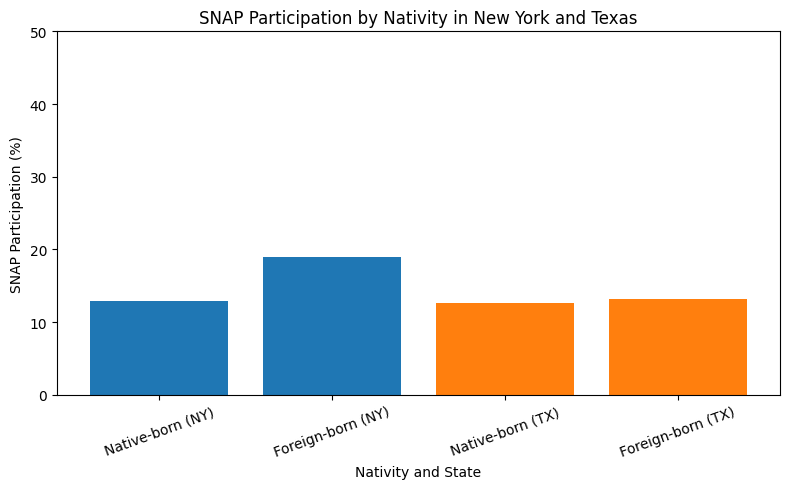

In [59]:
import matplotlib.pyplot as plt

# Create bar chart
plt.figure(figsize=(8, 5))

# Plot bars
for state in snap_rates["state"].unique():
    subset = snap_rates[snap_rates["state"] == state] 
 
    plt.bar(
        subset["nativity"] + " (" + state + ")",
        subset["snap_percent"],
        label=state
    )

# Labels and title
plt.ylabel("SNAP Participation (%)")
plt.xlabel("Nativity and State")
plt.title("SNAP Participation by Nativity in New York and Texas")

plt.ylim(0,50) # ensures axis goes from 0% to 50% 

# Rotate x labels for readability
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



### Logistic Regression Analysis
To further explore the relationship between nativity and SNAP participation, a logistic regression model was estimated. Logistic regression is appropriate because the dependent variable (SNAP participation) is binary, indicating whether an individual reported receiving SNAP benefits.

The model evaluates whether being foreign-born, age, and state of residence (Texas vs. New York) are associated with the probability of receiving SNAP benefits. Texas is included as a binary indicator variable to compare outcomes between the two states.

This analysis helps test whether differences observed in the descriptive statistics remain significant when controlling for additional demographic characteristics.

In [60]:
import statsmodels.api as sm

# Create a dataset containing only the variables needed for the regression model
model_df = df_states[["snap", "foreign_born", "AGE", "state"]].dropna()

# Create a state indicator variable
# Texas = 1, New York = 0
model_df["TX"] = (model_df["state"] == "TX").astype(int)

# Quick check of the dataset size after removing missing values
model_df.shape

# Define predictor variables (independent variables)
X = model_df[["foreign_born", "AGE", "TX"]]

# Add a constant (intercept) term to the regression model
X = sm.add_constant(X)

# Define the dependent variable (SNAP participation)
y = model_df["snap"]

# Fit logistic regression model
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# Display regression results
result.summary()

Optimization terminated successfully.
         Current function value: 0.386751
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                   snap   No. Observations:              2279911
Model:                          Logit   Df Residuals:                  2279907
Method:                           MLE   Df Model:                            3
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                 0.01579
Time:                        20:41:03   Log-Likelihood:            -8.8176e+05
converged:                       True   LL-Null:                   -8.9590e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.3411      0.004   -303.637      0.000      -1.350      -1.332
foreign_born     0.3678      0.005     76.235      0.000       0.358       0.377
AGE             -0.0133   8.67e-05   -153.346      0.000      -0.013      -0.013
TX              -0.1488      0.004    -37.679      0.000      -0.157      -0.141
================================================================================
"""

### Analysis of SNAP Participation 
Descriptive statistics from the recoded dataset show that approximately 13.3% of individuals reported receiving SNAP benefits, while 18.7% of the sample is foreign-born. These values are consistent with national demographic patterns and suggest that the variables were recoded correctly before analysis. Examining these initial distributions provides a useful starting point for understanding how SNAP participation varies across demographic groups.
To better illustrate differences across groups, SNAP participation rates were calculated by state and nativity status and displayed using a bar chart. The visualization highlights several notable patterns. Foreign-born individuals in New York show the highest SNAP participation rate at approximately 19%, compared to about 13% among native-born individuals in the same state. In Texas, SNAP participation rates are lower overall and the difference between nativity groups is smaller, with both native-born and foreign-born individuals reporting participation rates near 13%. Presenting the data visually makes these differences easier to observe and suggests that both nativity and state of residence may be associated with variation in SNAP participation.
While descriptive statistics and visualizations help reveal patterns in the data, they do not account for the influence of other demographic factors. To further examine these relationships, a logistic regression model was estimated to test whether nativity, age, and state of residence are associated with the likelihood of receiving SNAP benefits.
The regression results indicate that foreign-born individuals are more likely to receive SNAP benefits compared to native-born individuals, holding age and state constant. The positive coefficient for the foreign-born variable (0.368) suggests higher log-odds of SNAP participation among this group. This finding aligns with the descriptive statistics and visualization, which showed higher SNAP participation among foreign-born individuals in New York.
Age also appears to influence SNAP participation. The negative coefficient for AGE (- 0.013) indicates that older individuals are less likely to report receiving SNAP benefits compared to younger individuals. This relationship suggests that SNAP participation may be more common among younger populations within the dataset.
State differences were also observed in the model. The negative coefficient for Texas (- 0.149) indicates that individuals residing in Texas have lower odds of receiving SNAP benefits compared to individuals living in New York when controlling for nativity and age. Overall, the regression results confirm that patterns observed in the descriptive statistics and visualization remain significant even after accounting for demographic characteristics.


### Conclusion 
This exploratory analysis examined whether nativity status, age, and state of residence are associated with differences in SNAP participation among individuals in New York and Texas. The results of the logistic regression model support the initial hypothesis that demographic characteristics and location are related to variation in SNAP usage. Foreign-born individuals in the dataset showed higher odds of receiving SNAP benefits compared to native-born individuals, while older individuals were less likely to report participation. In addition, state-level differences were observed, with individuals residing in Texas showing lower odds of SNAP participation compared to those living in New York. These findings suggest that both demographic and geographic factors may play a role in shaping participation in public assistance programs.
Although the results align with the general expectation that nativity status may influence SNAP participation, the difference between native-born and foreign-born individuals was not as large as initially expected. Prior to conducting the analysis, it seemed possible that the differences would be greater, particularly in Texas given the state’s more restrictive political climate regarding public assistance programs. However, the results show that SNAP participation rates between nativity groups in Texas are relatively similar, while the largest difference appears in New York where foreign-born individuals show higher participation rates. This outcome raises additional questions about how economic conditions, state policies, and immigrant integration may influence participation patterns.
One important limitation of this analysis is that the dataset only identifies whether an individual reported receiving SNAP benefits at the time of the survey. The data does not provide information about how long individuals have been participating in SNAP, which limits the ability to understand whether participation represents short-term assistance or longer-term reliance on the program. Previous literature suggests that while immigrants may initially experience greater economic hardship, many improve their economic standing over time and may rely less on public assistance in the long run. This raises the possibility that foreign-born individuals may be using SNAP for shorter periods of time compared to native-born populations, an idea that could not be tested with the current dataset.
Future research could build on this exploratory analysis by examining the duration of SNAP participation, changes in income over time, or additional demographic variables such as education level, employment status, and years since immigration. Expanding the dataset to include more states or multiple years of data would also allow for a broader understanding of how policy environments and economic conditions influence SNAP participation across different populations. Future studies could apply more advanced statistical or machine learning approaches to better understand patterns of program participation and identify factors that contribute to economic stability among both native-born and immigrant populations.
